# 6G Network Optimisation — DQN vs PPO Agent Evaluation
This notebook evaluates how the **DQN** and **PPO** agents improve the 6G network using the metrics defined in `utils/metrics.py`.

Metrics tracked per episode:
- **SINR** — Signal-to-Interference-plus-Noise Ratio
- **Throughput** — Shannon capacity per user (bps)
- **Spectral Efficiency** — bits/s/Hz
- **Fairness Index** — Jain's fairness across users
- **Avg Latency** — proxy via queue length / service rate
- **Episode Reward Summary** — total, mean, min, max reward

In [1]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

from envs.network_env import NetworkEnv
from agents.dqn_agent import DQNAgent
from models.encoder import GraphEncoder
from utils.metrics import (
    compute_sinr, compute_throughput, compute_spectral_efficiency,
    compute_fairness_index, compute_avg_latency, summarize_episode,
)

CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "config.yaml")
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
print(f"Device: {DEVICE}")
print("Network config:", config["network"])

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\nirmi\Desktop\LABS\PF LAB\6g-gnn-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Network config: {'num_base_stations': 12, 'num_users': 40, 'area_size': 3000, 'frequency_ghz': 28, 'max_bandwidth_mhz': 400, 'max_edge_distance': 900}


## 1. Load Pretrained GNN Encoder

In [ ]:
gnn_cfg = config.get("gnn", {})
encoder = GraphEncoder(
    in_channels=gnn_cfg.get("in_channels", 5),
    hidden_channels=gnn_cfg.get("hidden_channels", 128),
    out_channels=gnn_cfg.get("out_channels", 64),
    num_layers=gnn_cfg.get("num_layers", 4),
    dropout=gnn_cfg.get("dropout", 0.2),
).to(DEVICE)

GNN_PATH = os.path.join(RESULTS_DIR, "gnn_pretrained.pt")
if os.path.exists(GNN_PATH):
    state_dict = torch.load(GNN_PATH, map_location=DEVICE, weights_only=True)
    expected_keys = set(encoder.gnn.state_dict().keys())
    loaded_keys   = set(state_dict.keys())
    if expected_keys != loaded_keys:
        print("WARNING: Checkpoint architecture mismatch!")
        print("  Missing keys :", expected_keys - loaded_keys)
        print("  Unexpected   :", loaded_keys - expected_keys)
        print("  → Run train_gnn.ipynb first to generate a compatible checkpoint.")
    else:
        encoder.gnn.load_state_dict(state_dict)
        print(f"Loaded pretrained GNN from {GNN_PATH}")
else:
    print("WARNING: No pretrained GNN found — run train_gnn.ipynb first.")

encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

Loaded pretrained GNN from c:\Users\nirmi\Desktop\LABS\PF LAB\6g-gnn-project\results\gnn_pretrained.pt


## 2. Load DQN Agent

In [4]:
env_tmp = NetworkEnv(config)
env_tmp.reset()
state_dim = env_tmp.get_gnn_state(encoder, DEVICE).shape[0]
action_dim = env_tmp.action_space.n
print(f"state_dim={state_dim}, action_dim={action_dim}")

dqn_agent = DQNAgent(state_dim, action_dim, config)

checkpoints = sorted(
    [f for f in os.listdir(RESULTS_DIR) if f.startswith("dqn_ep") and f.endswith(".pt")],
    key=lambda x: int(x.replace("dqn_ep", "").replace(".pt", ""))
)
print("Available DQN checkpoints:", checkpoints)

if checkpoints:
    dqn_agent.load(os.path.join(RESULTS_DIR, checkpoints[-1]))
    dqn_agent.epsilon = 0.0
    print(f"Loaded: {checkpoints[-1]}")
else:
    print("No DQN checkpoint found — using untrained agent.")

state_dim=3432, action_dim=480
Available DQN checkpoints: ['dqn_ep50.pt', 'dqn_ep100.pt', 'dqn_ep150.pt', 'dqn_ep200.pt', 'dqn_ep250.pt', 'dqn_ep300.pt', 'dqn_ep350.pt', 'dqn_ep400.pt', 'dqn_ep450.pt', 'dqn_ep500.pt', 'dqn_ep550.pt', 'dqn_ep600.pt', 'dqn_ep650.pt', 'dqn_ep700.pt', 'dqn_ep750.pt', 'dqn_ep800.pt']
Loaded: dqn_ep800.pt


## 3. Evaluation Helper

In [5]:
def evaluate_agent(agent_fn, env, encoder, device, n_episodes=10, use_gnn_state=True):
    net = config["network"]
    BW = net["max_bandwidth_mhz"] * 1e6 / net["num_users"]
    results = defaultdict(list)

    for ep in range(n_episodes):
        obs = env.reset()
        done = False
        ep_rewards = []
        ep_sinr, ep_tp, ep_se, ep_fairness, ep_latency = [], [], [], [], []

        while not done:
            state = env.get_gnn_state(encoder, device) if use_gnn_state else obs
            action = agent_fn(state)
            obs, reward, done, info = env.step(action)
            ep_rewards.append(reward)

            throughputs = env._compute_throughputs()

            sinr_vals = []
            for u in range(env.num_users):
                bs = env.allocations[u]
                dist = np.linalg.norm(env.user_positions[u] - env.bs_positions[bs]) + 1e-3
                signal = env.tx_power / (dist ** env.path_loss_exp)
                interference = sum(
                    env.tx_power / (np.linalg.norm(env.user_positions[u] - env.bs_positions[env.allocations[v]]) ** env.path_loss_exp + 1e-3)
                    for v in range(env.num_users) if v != u
                )
                sinr_vals.append(compute_sinr(signal, interference, env.noise_power))

            mean_tp  = float(np.mean(throughputs))
            ep_sinr.append(float(np.mean(sinr_vals)))
            ep_tp.append(mean_tp)
            ep_se.append(float(np.mean([compute_spectral_efficiency(tp, BW) for tp in throughputs])))
            ep_fairness.append(compute_fairness_index(throughputs))
            queue_lengths = np.maximum(env.demands - throughputs, 0)
            ep_latency.append(compute_avg_latency(queue_lengths, service_rate=mean_tp))

        summary = summarize_episode(ep_rewards)
        results["total_reward"].append(summary["total_reward"])
        results["mean_reward"].append(summary["mean_reward"])
        results["sinr"].append(float(np.mean(ep_sinr)))
        results["throughput_mbps"].append(float(np.mean(ep_tp)) / 1e6)
        results["spectral_efficiency"].append(float(np.mean(ep_se)))
        results["fairness"].append(float(np.mean(ep_fairness)))
        results["latency"].append(float(np.mean(ep_latency)))

    return dict(results)

## 4. Baseline — Random Policy

In [6]:
N_EVAL = 20
env_eval = NetworkEnv(config)

print("Evaluating Random policy...")
random_results = evaluate_agent(
    lambda state: env_eval.action_space.sample(),
    env_eval, encoder, DEVICE, n_episodes=N_EVAL, use_gnn_state=False
)
print(f"  Avg total reward : {np.mean(random_results['total_reward']):.4f}")
print(f"  Avg throughput   : {np.mean(random_results['throughput_mbps']):.4f} Mbps")
print(f"  Avg fairness     : {np.mean(random_results['fairness']):.4f}")

Evaluating Random policy...
  Avg total reward : 21.9227
  Avg throughput   : 4.8048 Mbps
  Avg fairness     : 0.1152


## 5. DQN Agent Evaluation

In [7]:
print("Evaluating DQN agent...")
dqn_results = evaluate_agent(
    lambda state: dqn_agent.select_action(state),
    env_eval, encoder, DEVICE, n_episodes=N_EVAL, use_gnn_state=True
)
print(f"  Avg total reward : {np.mean(dqn_results['total_reward']):.4f}")
print(f"  Avg throughput   : {np.mean(dqn_results['throughput_mbps']):.4f} Mbps")
print(f"  Avg fairness     : {np.mean(dqn_results['fairness']):.4f}")

Evaluating DQN agent...
  Avg total reward : 19.6122
  Avg throughput   : 4.1977 Mbps
  Avg fairness     : 0.2204


## 7. DQN Checkpoint Progression

In [9]:
ckpt_rewards, ckpt_fairness, ckpt_throughput = {}, {}, {}

for ckpt_file in checkpoints:
    ep_num = int(ckpt_file.replace("dqn_ep", "").replace(".pt", ""))
    a = DQNAgent(state_dim, action_dim, config)
    a.load(os.path.join(RESULTS_DIR, ckpt_file))
    a.epsilon = 0.0
    res = evaluate_agent(lambda s, ag=a: ag.select_action(s), env_eval, encoder, DEVICE, n_episodes=5)
    ckpt_rewards[ep_num]    = np.mean(res["total_reward"])
    ckpt_fairness[ep_num]   = np.mean(res["fairness"])
    ckpt_throughput[ep_num] = np.mean(res["throughput_mbps"])
    print(f"  ep{ep_num:4d} | reward={ckpt_rewards[ep_num]:.4f} | fairness={ckpt_fairness[ep_num]:.4f} | tp={ckpt_throughput[ep_num]:.4f} Mbps")

ckpt_eps = sorted(ckpt_rewards.keys())

  ep  50 | reward=13.2888 | fairness=0.1104 | tp=4.5621 Mbps
  ep 100 | reward=12.2787 | fairness=0.0966 | tp=2.5359 Mbps
  ep 150 | reward=18.7695 | fairness=0.1647 | tp=5.1710 Mbps
  ep 200 | reward=13.7288 | fairness=0.1192 | tp=2.8919 Mbps
  ep 250 | reward=14.1804 | fairness=0.1427 | tp=0.8469 Mbps
  ep 300 | reward=10.8675 | fairness=0.0545 | tp=3.6066 Mbps
  ep 350 | reward=10.9253 | fairness=0.0679 | tp=7.1873 Mbps
  ep 400 | reward=14.6642 | fairness=0.1274 | tp=2.7365 Mbps
  ep 450 | reward=11.2516 | fairness=0.1010 | tp=0.6511 Mbps
  ep 500 | reward=14.4186 | fairness=0.1306 | tp=2.3398 Mbps
  ep 550 | reward=14.6374 | fairness=0.1459 | tp=3.6488 Mbps
  ep 600 | reward=14.0787 | fairness=0.1107 | tp=1.7482 Mbps
  ep 650 | reward=9.5867 | fairness=0.0748 | tp=0.4615 Mbps
  ep 700 | reward=12.2969 | fairness=0.0960 | tp=3.3640 Mbps
  ep 750 | reward=13.1847 | fairness=0.1326 | tp=1.6107 Mbps
  ep 800 | reward=17.1989 | fairness=0.1823 | tp=0.9323 Mbps


## 8. Visualisation

In [1]:
agents = {"Random": random_results, "DQN": dqn_results}
if PPO_AVAILABLE:
    agents["PPO"] = ppo_results

COLORS = {"Random": "#9e9e9e", "DQN": "#1976D2", "PPO": "#E64A19"}
METRICS = ["total_reward", "throughput_mbps", "fairness", "spectral_efficiency", "sinr", "latency"]
LABELS  = ["Total Reward", "Throughput (Mbps)", "Fairness Index",
           "Spectral Eff. (b/s/Hz)", "Mean SINR", "Avg Latency (proxy)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, metric, label in zip(axes.flatten(), METRICS, LABELS):
    for name, res in agents.items():
        vals = res[metric]
        ax.plot(vals, alpha=0.3, color=COLORS[name])
        ax.axhline(np.mean(vals), linestyle="--", linewidth=2, color=COLORS[name],
                   label=f"{name} (μ={np.mean(vals):.3f})")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Episode")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("6G Network — Agent Comparison (utils/metrics.py)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
os.makedirs(os.path.join(RESULTS_DIR, "plots"), exist_ok=True)
plt.savefig(os.path.join(RESULTS_DIR, "plots", "agent_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/plots/agent_comparison.png")

NameError: name 'random_results' is not defined

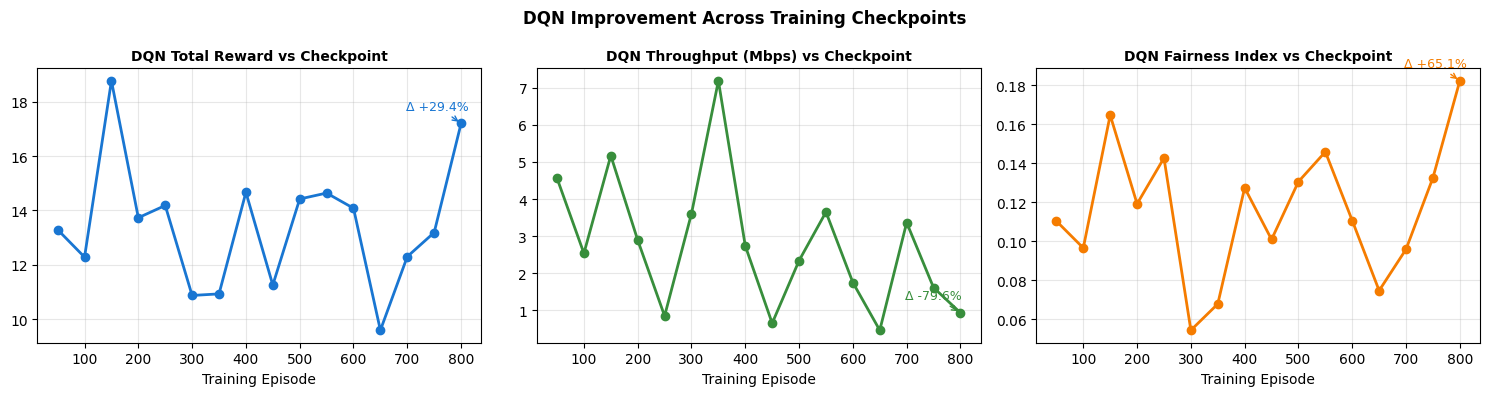

Saved → results/plots/dqn_checkpoint_progression.png


In [11]:
# DQN checkpoint progression
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title, color in zip(
    axes,
    [ckpt_rewards, ckpt_throughput, ckpt_fairness],
    ["Total Reward vs Checkpoint", "Throughput (Mbps) vs Checkpoint", "Fairness Index vs Checkpoint"],
    ["#1976D2", "#388E3C", "#F57C00"],
):
    vals = [data[e] for e in ckpt_eps]
    ax.plot(ckpt_eps, vals, marker="o", color=color, linewidth=2)
    ax.set_title(f"DQN {title}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Training Episode")
    ax.grid(True, alpha=0.3)
    if len(vals) >= 2:
        pct = ((vals[-1] - vals[0]) / (abs(vals[0]) + 1e-9)) * 100
        ax.annotate(f"Δ {pct:+.1f}%", xy=(ckpt_eps[-1], vals[-1]),
                    xytext=(-40, 10), textcoords="offset points",
                    fontsize=9, color=color, arrowprops=dict(arrowstyle="->", color=color))

fig.suptitle("DQN Improvement Across Training Checkpoints", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "plots", "dqn_checkpoint_progression.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/plots/dqn_checkpoint_progression.png")

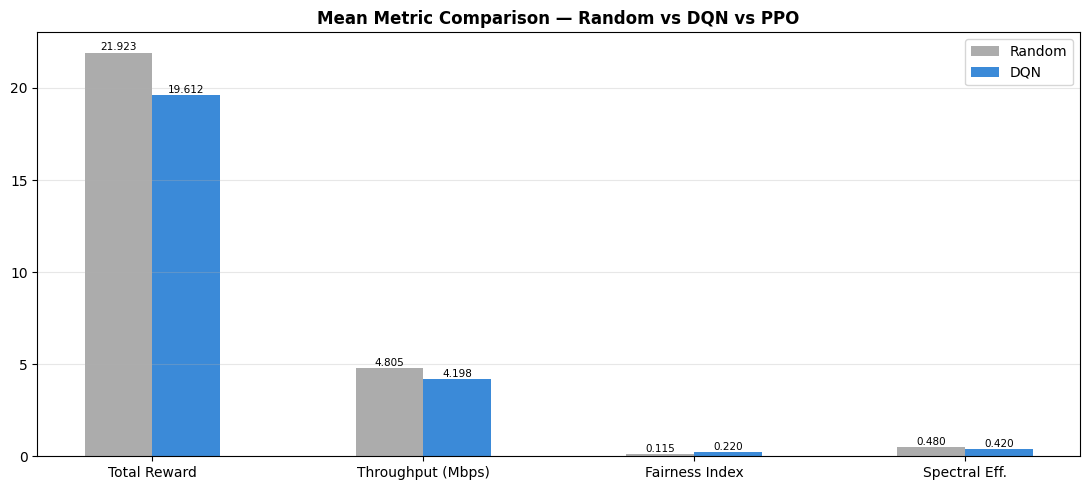

Saved → results/plots/bar_comparison.png


In [12]:
# Bar chart summary
bar_metrics = ["total_reward", "throughput_mbps", "fairness", "spectral_efficiency"]
bar_labels  = ["Total Reward", "Throughput (Mbps)", "Fairness Index", "Spectral Eff."]
x = np.arange(len(bar_metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, res) in enumerate(agents.items()):
    means = [np.mean(res[m]) for m in bar_metrics]
    bars = ax.bar(x + i * width, means, width, label=name, color=COLORS[name], alpha=0.85)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width * (len(agents) - 1) / 2)
ax.set_xticklabels(bar_labels)
ax.set_title("Mean Metric Comparison — Random vs DQN vs PPO", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "plots", "bar_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/plots/bar_comparison.png")

## 9. Numerical Summary Table

In [13]:
all_metrics = [
    ("Total Reward",          "total_reward"),
    ("Mean Step Reward",      "mean_reward"),
    ("Throughput (Mbps)",     "throughput_mbps"),
    ("Spectral Eff (b/s/Hz)", "spectral_efficiency"),
    ("Fairness Index",        "fairness"),
    ("Mean SINR",             "sinr"),
    ("Avg Latency (proxy)",   "latency"),
]

col_w = 14
header = f"{'Metric':<28}" + "".join(f"{n:>{col_w}}" for n in agents)
print(header)
print("-" * len(header))
for label, key in all_metrics:
    row = f"{label:<28}" + "".join(f"{np.mean(res[key]):>{col_w}.4f}" for res in agents.values())
    print(row)

print()
print("=== DQN improvement over Random ===")
for label, key in all_metrics:
    base = np.mean(random_results[key])
    improved = np.mean(dqn_results[key])
    pct = ((improved - base) / (abs(base) + 1e-9)) * 100
    direction = "▲" if pct > 0 else "▼"
    print(f"  {label:<28} {direction} {abs(pct):.1f}%")

if PPO_AVAILABLE:
    print()
    print("=== PPO improvement over Random ===")
    for label, key in all_metrics:
        base = np.mean(random_results[key])
        improved = np.mean(ppo_results[key])
        pct = ((improved - base) / (abs(base) + 1e-9)) * 100
        direction = "▲" if pct > 0 else "▼"
        print(f"  {label:<28} {direction} {abs(pct):.1f}%")

Metric                              Random           DQN
--------------------------------------------------------
Total Reward                       21.9227       19.6122
Mean Step Reward                    0.1096        0.0981
Throughput (Mbps)                   4.8048        4.1977
Spectral Eff (b/s/Hz)               0.4805        0.4198
Fairness Index                      0.1152        0.2204
Mean SINR                           0.1632        0.0672
Avg Latency (proxy)                11.1436      135.7044

=== DQN improvement over Random ===
  Total Reward                 ▼ 10.5%
  Mean Step Reward             ▼ 10.5%
  Throughput (Mbps)            ▼ 12.6%
  Spectral Eff (b/s/Hz)        ▼ 12.6%
  Fairness Index               ▲ 91.2%
  Mean SINR                    ▼ 58.9%
  Avg Latency (proxy)          ▲ 1117.8%
